In [1]:
print("hellowworls")

hellowworls


In [4]:
# Install if needed
# pip install nltk scikit-learn pandas matplotlib seaborn wordcloud

import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from wordcloud import WordCloud

nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [3]:
!pip install nltk scikit-learn pandas matplotlib seaborn wordcloud


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import os
os.getcwd()
os.listdir()

['.anaconda',
 '.arduinoIDE',
 '.bash_history',
 '.conda',
 '.condarc',
 '.continuum',
 '.docker',
 '.gitconfig',
 '.idlerc',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.keras',
 '.kube',
 '.matplotlib',
 '.minikube',
 '.node_repl_history',
 '.rest-client',
 '.ssh',
 '.VirtualBox',
 '.virtual_documents',
 '.vscode',
 '1.cr.mti',
 '1.mpf',
 '16299',
 '24BAI0142.v',
 '24BAI0142.v.bak',
 '2bitmultiplier.v',
 '2bitmultiplier.v.bak',
 'a.class',
 'a.java',
 'ACM-TASK-DEVOPS',
 'ACM_DEVOPS_TASK',
 'anaconda_projects',
 'AppData',
 'Application Data',
 'asdc.v',
 'asdc.v.bak',
 'asupc.v',
 'asupc.v.bak',
 'aws-elastic-beanstalk-express-js-sample',
 'binaryaddersubtractor.v',
 'binaryaddersubtractor.v.bak',
 'c',
 'carrylookahead.v',
 'carrylookahead.v.bak',
 'cla.v',
 'comparater.v',
 'comparater.v.bak',
 'Contacts',
 'container-orchestration-project',
 'Cookies',
 'coubnter.v',
 'coubnter.v.bak',
 'CrossDevice',
 'day1--.v',
 'day1--.v.bak',
 'day1--tb.v',
 'day1--tb.v.bak',
 'DellIn

In [9]:
df=pd.read_csv(r"C:\Users\DELL\OneDrive\Desktop\sentiment analyser\nlptask.csv")
df.head()

,Unnamed: 0,id,created_at,source,original_text,lang,favorite_count,retweet_count,hashtags,user_mentions,place,compound,neg,neu,pos,sentiment
0,0,1386694264550270000,2021-04-26,"<a href=""http://twitter.com/download/android"" ...",RT @VP: The U.S. is working closely with the I...,en,0.0,0.0,NaN,VP,Alabama,0.0772,0.170,0.638,0.191,pos
1,1,1386694260213170000,2021-04-26,"<a href=""http://twitter.com/download/iphone"" r...",RT @JackPosobiec: Flip-Flop Fauci admits outdo...,en,0.0,0.0,NaN,JackPosobiec,NaN,-0.4019,0.398,0.442,0.159,neg
2,2,1386694256413320000,2021-04-26,"<a href=""http://twitter.com/download/iphone"" r...","RT @timmy315: Hi Twitter, I’m Tim Manning, the...",en,0.0,252.0,NaN,timmy315,NaN,0.0000,0.000,1.000,0.000,neu
3,3,1386694252017630000,2021-04-26,"<a href=""https://mobile.twitter.com"" rel=""nofo...",RT @itsaadee: Praying for #India as the countr...,en,0.0,2.0,"India, Covid",itsaadee,NaN,-0.4215,0.306,0.522,0.172,neg
4,4,1386694248284700000,2021-04-26,"<a href=""https://mobile.twitter.com"" rel=""nofo...",Rapid Investment in Nursing to Strengthen the ...,en,0.0,7937.0,NaN,NaN,UK,0.3182,0.000,0.723,0.277,pos


In [10]:

print(df.columns)
print(df[['original_text', 'sentiment']].head())

Index(['Unnamed: 0', 'id', 'created_at', 'source', 'original_text', 'lang',
       'favorite_count', 'retweet_count', 'hashtags', 'user_mentions', 'place',
       'compound', 'neg', 'neu', 'pos', 'sentiment'],
      dtype='object')
                                       original_text sentiment
0  RT @VP: The U.S. is working closely with the I...       pos
1  RT @JackPosobiec: Flip-Flop Fauci admits outdo...       neg
2  RT @timmy315: Hi Twitter, I’m Tim Manning, the...       neu
3  RT @itsaadee: Praying for #India as the countr...       neg
4  Rapid Investment in Nursing to Strengthen the ...       pos


In [11]:
df = df[['original_text', 'sentiment']].dropna()

In [12]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

In [13]:

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|@\w+|#\w+", "", text)  # remove URLs, mentions, hashtags
    text = re.sub(r"[^a-z\s]", "", text)                # keep only letters
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]
    tokens = [stemmer.stem(w) for w in tokens]
    return " ".join(tokens)

In [14]:

df['clean_text'] = df['original_text'].apply(clean_text)


In [15]:
X = df['clean_text']
y = df['sentiment']   # pos / neg / neu

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [17]:
vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [18]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [19]:
y_pred = model.predict(X_test_vec)

In [20]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9462437395659432

Classification Report:
               precision    recall  f1-score   support

         neg       0.96      0.88      0.92      5812
         neu       0.93      0.99      0.96     10904
         pos       0.96      0.93      0.95      7244

    accuracy                           0.95     23960
   macro avg       0.95      0.93      0.94     23960
weighted avg       0.95      0.95      0.95     23960



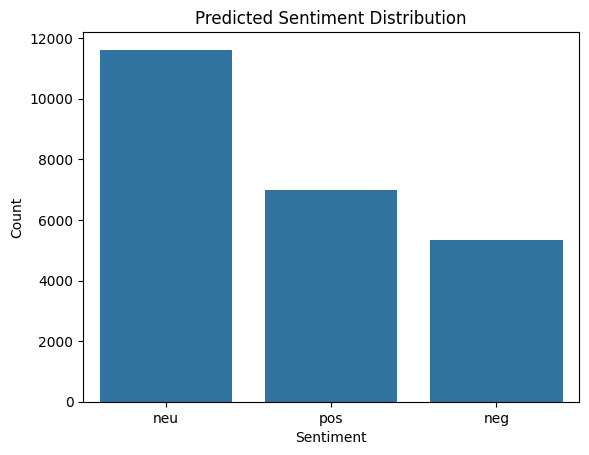

In [21]:
sns.countplot(x=y_pred)
plt.title("Predicted Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

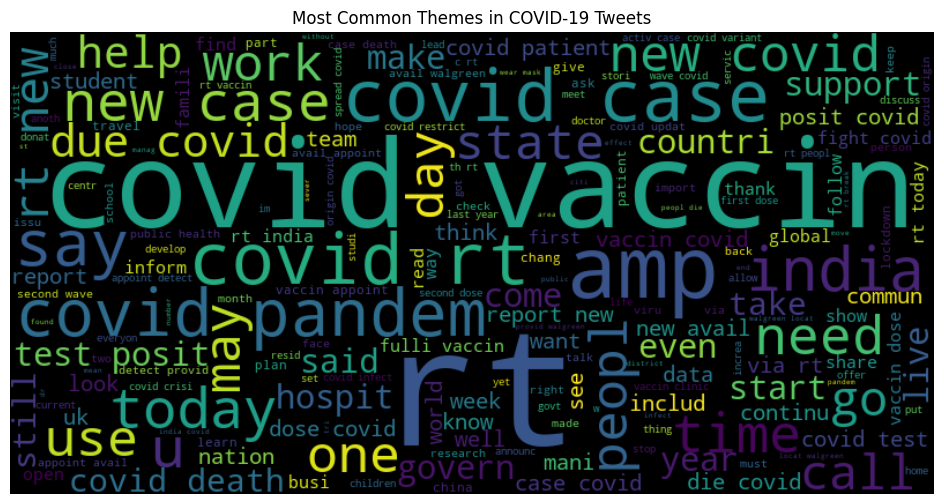

In [22]:
all_text = " ".join(df['clean_text'])
wc = WordCloud(width=800, height=400, background_color='black').generate(all_text)
plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.title("Most Common Themes in COVID-19 Tweets")
plt.show()


In [23]:
def predict_sentiment(text):
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    return model.predict(vec)[0]

In [24]:
print(predict_sentiment("Hospitals are full and the situation is scary"))

neu


In [25]:
print(predict_sentiment("New covid guidelines announced today"))

neu


In [26]:
print(predict_sentiment("Vaccination drive is successful and people are hopeful"))

pos


In [31]:
print(predict_sentiment("This is the end of life and i guess i am next and i feel safe but i am dying"))

neg


Accuracy: 0.9462437395659432

Classification Report:
               precision    recall  f1-score   support

         neg       0.96      0.88      0.92      5812
         neu       0.93      0.99      0.96     10904
         pos       0.96      0.93      0.95      7244

    accuracy                           0.95     23960
   macro avg       0.95      0.93      0.94     23960
weighted avg       0.95      0.95      0.95     23960



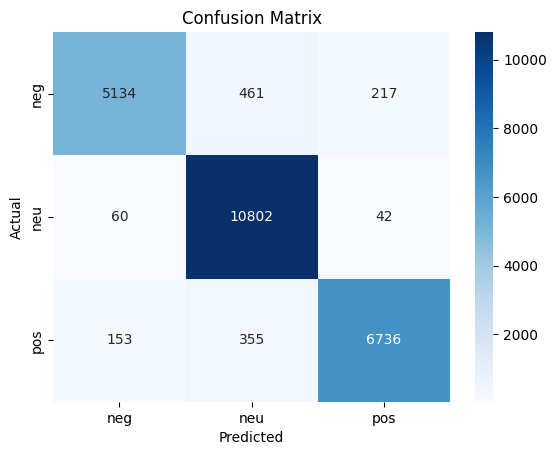

In [32]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [33]:
print(predict_sentiment("death"))

neg


In [34]:
print(predict_sentiment("safe"))

pos


In [36]:
print(predict_sentiment("Pranav Suresh"))

neu


In [37]:
print(predict_sentiment("Pranav Suresh"))

neu


In [38]:
print(predict_sentiment("1234"))

neu
